# Hacia una medicina preventiva en hipertensión arterial

La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. La finalidad es doble: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas.

## Objetivos

- Aplicar técnicas de clasificación basadas en árboles de decisión y K-vecinos más cercanos para construir modelos predictivos que permitan identificar el riesgo de desarrollar hipertensión.
- Identificar los factores más relevantes que influyen en el desarrollo de la hipertensión a partir del análisis de los datos.

# 1. Exploración y Perfilamiento de Datos

Exploración y perfilamiento de los datos, utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje.

## Carga de datos

Se carga el conjunto de datos desde el archivo CSV utilizando codificación latin-1 y delimitador punto y coma. Se visualizan las primeras filas para verificar la estructura del dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
data_raw = pd.read_csv("../../data/stage-2/Datos_hipertension.csv", encoding='latin-1', delimiter=';')
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## Dimensiones del dataset

Se verifican las dimensiones del conjunto de datos para conocer el número de registros y variables. El dataset contiene 1990 registros y 13 variables.

In [3]:
data_raw.shape

(1990, 13)

## Información general

Se examina la estructura del dataset, incluyendo tipos de datos y valores no nulos. Todas las columnas contienen 1990 valores no nulos, indicando que no hay valores faltantes en el dataset.

In [4]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   str    
 7   Historia_Familiar   1990 non-null   str    
 8   Actividad_Fisica    1990 non-null   str    
 9   Fumador             1990 non-null   str    
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   str    
 12  Hipertension        1990 non-null   str    
dtypes: float64(5), int64(2), str(6)
memory usage: 202.2 KB


## Estadísticas descriptivas

Se calculan las estadísticas descriptivas de las variables numéricas para identificar valores extremos y distribución de los datos. Se observan posibles valores atípicos en variables como Colesterol y Duración_Sueño.

In [5]:
data_raw.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
mean,50.379397,8.531608,4.974372,209.526935,6.452613,26.013869,105.642211
std,19.439669,1.994245,3.144396,75.791456,1.540354,4.507425,22.541122
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.325000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


## Detección y eliminación de duplicados

Se identifican y eliminan registros duplicados del dataset. Se encontraron 4 registros duplicados que fueron eliminados exitosamente.

In [6]:
before_drop = data_raw.duplicated().sum()
data = data_raw.drop_duplicates()
after_drop = data.duplicated().sum()
print(f"Before dropping duplicates: {before_drop},", f"After dropping duplicates: {after_drop}")

Before dropping duplicates: 4, After dropping duplicates: 0


## Verificación de valores faltantes

Se verifica la presencia de valores ausentes en cada columna del dataset. No se encontraron valores faltantes en ninguna variable.

In [7]:
data_raw.isnull().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

## Detección visual de outliers

Se generan gráficos de caja para identificar visualmente la presencia de valores atípicos en las variables numéricas. Los gráficos revelan la presencia de valores atípicos en las variables Ingesta_Sal, Colesterol, Duración_Sueño, BMI y Glucosa.

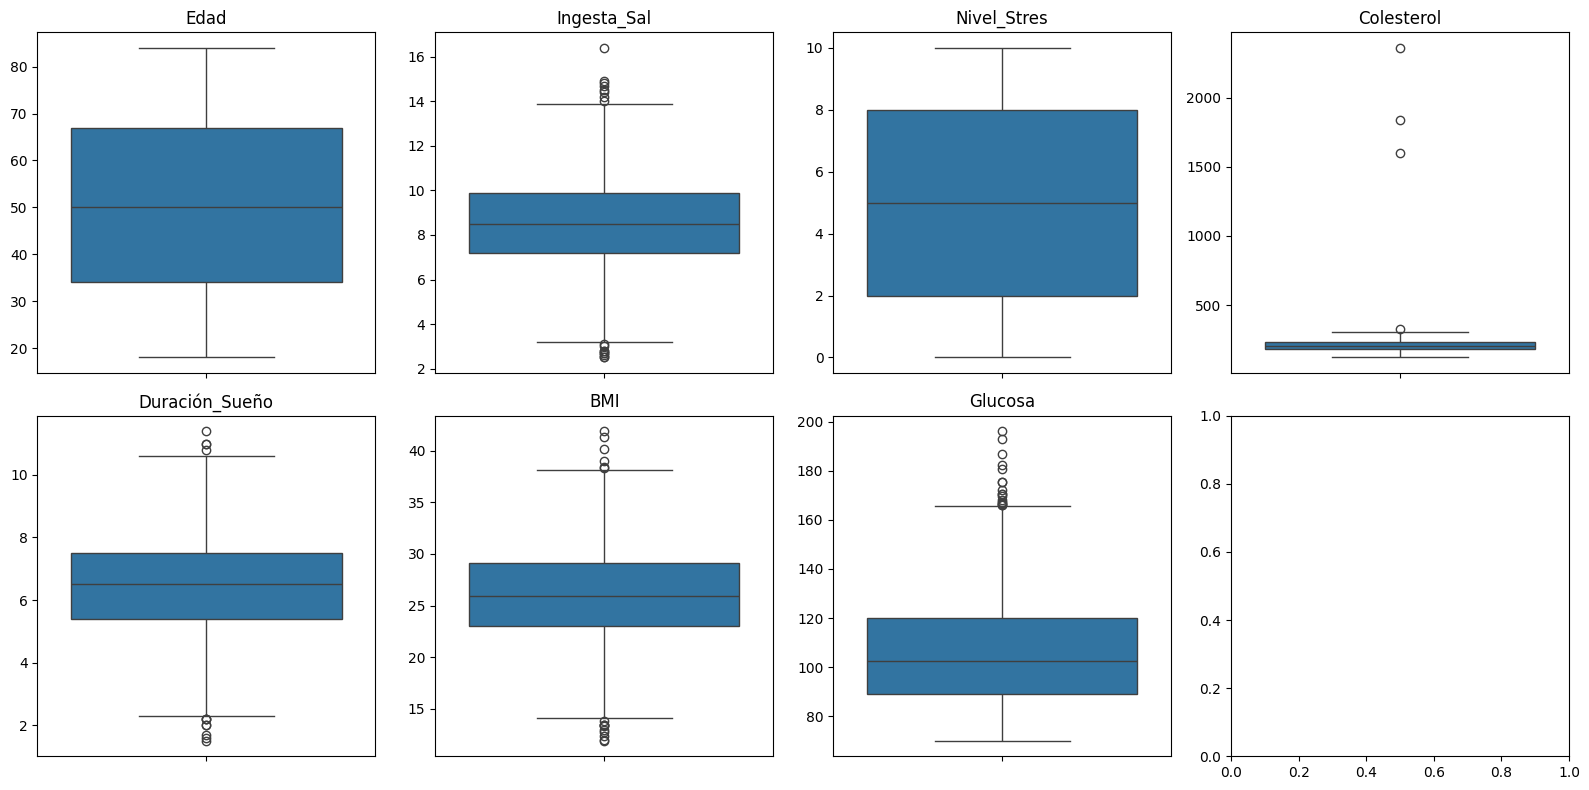

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

columnas = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 
            'Duración_Sueño', 'BMI', 'Glucosa']

for i, col in enumerate(columnas):
    sns.boxplot(y=data_raw[col], ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Conclusiones de la Exploración de Datos

## Resumen General

El dataset de hipertensión contiene 1990 registros con 13 variables (7 numéricas y 6 categóricas). El análisis exploratorio revela un conjunto de datos en buen estado general.

## Calidad de los Datos

### Valores Faltantes
No se identificaron valores faltantes en ninguna variable.

### Registros Duplicados
Se detectaron y eliminaron 4 registros duplicados (0.3% del dataset).

## Valores Atípicos

Se identificaron outliers en cinco variables numéricas:

- **Colesterol**: Valor máximo de 2360 mg/dL, muy por encima del percentil 75 (231.7 mg/dL)
- **Ingesta_Sal**: Máximo de 16.4 g/día vs percentil 75 de 9.9 g/día
- **Duración_Sueño**: Valores extremos entre 1.5 y 11.4 horas
- **BMI**: Outliers en ambos extremos del rango
- **Glucosa**: Valores elevados que requieren evaluación

## Estado del Dataset

El dataset presenta buena calidad con estructura completa y sin valores faltantes. Los principales aspectos a considerar en la preparación de datos son:

- Tratamiento de valores atípicos en variables numéricas
- Codificación de las 6 variables categóricas
- Normalización o estandarización de variables numéricas
- División apropiada entre entrenamiento y prueba

# 2. Construcción del pipeline de limpieza y preparación de los datos

Construcción del pipeline de limpieza y preparación de los datos, justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior.

## Identificación de tipos de variables

Se identifican automáticamente las variables numéricas y categóricas del dataset para aplicar las transformaciones apropiadas a cada tipo.

In [9]:
numeric_features = list(data_raw.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(data_raw.select_dtypes(exclude=['int64', 'float64']).columns)
categorical_features.remove('Hipertension')  # Remove target variable from categorical features

print(f"Numeric features:\n{numeric_features}")
print(f"\nCategorical features:\n{categorical_features}")

Numeric features:
['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']

Categorical features:
['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon']


## Selección de transformadores

### RobustScaler para variables numéricas
Se utiliza RobustScaler en lugar de StandardScaler porque el análisis exploratorio reveló outliers significativos (ejemplo: Colesterol con valor máximo de 2360 vs percentil 75 de 231.7). RobustScaler usa la mediana y el rango intercuartílico, que no se ven afectados por valores extremos.

### OneHotEncoder para variables categóricas
Se codifican las variables categóricas en formato numérico. Se usa `drop='first'` para evitar multicolinealidad y `handle_unknown='ignore'` para manejar categorías no vistas en entrenamiento.

In [10]:
numeric_transformer = RobustScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

## Pipeline de transformación

Se crea un pipeline que aplica las transformaciones apropiadas a cada tipo de variable de forma automática y organizada.

In [11]:
encoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

steps = [
    ('encoder', encoder),
]

transform_pipeline = Pipeline(steps).set_output(transform='pandas')
transform_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrice

## División de datos

Se divide el dataset en conjuntos de entrenamiento (80%) y prueba (20%) utilizando un random_state fijo para garantizar reproducibilidad de los resultados.

In [12]:
train, test = train_test_split(data, test_size=0.2, random_state=77)
train.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
1444,37,6.7,3,194.7,8.6,21.1,BloqueadorBeta,No,Alta,No,70.0,No,No
1917,34,9.9,2,192.8,4.8,21.4,InhibidorACE,No,Baja,Si,105.7,No,No
342,75,7.3,2,209.4,5.9,35.2,Ninguna,Si,Alta,No,131.7,No,Si
740,50,6.8,7,213.3,4.5,22.5,BloqueadorBeta,Si,Moderada,No,117.2,No,No
1706,49,6.5,0,189.8,5.7,21.0,Ninguna,No,Moderada,Si,132.3,No,No


## Separación de variables

Se separan las características (X) de la variable objetivo (y). La variable objetivo "Hipertension" indica si el paciente tiene o no hipertensión.

In [13]:
x_train = train.drop(['Hipertension'], axis=1)
y_train = train['Hipertension']

# 3. Construcción de un modelo de árboles de decisión 

Construcción de un modelo de árboles de decisión. Utiliza la función GridSeacrhCV, con el siguiente espacio de búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}.

In [14]:
decision_tree = DecisionTreeClassifier(random_state=0)

decision_tree_steps = [
    ('encoder', encoder),
    ('model', decision_tree)
]

decision_tree_pipeline = Pipeline(decision_tree_steps).set_output(transform='pandas')

decision_tree_pipeline 


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [15]:
param_grid = {'model__criterion': ['gini', 'entropy'],
              'model__max_depth': [4,6,8,10,12],
              'model__min_samples_split': [3, 4, 5]}

In [16]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

In [17]:
grid = GridSearchCV(decision_tree_pipeline, param_grid, cv=kfold)

In [18]:
grid.fit(x_train, y_train)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 6, ...], 'model__min_samples_split': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [19]:
print("Mejores parámetros: {}".format(grid.best_params_))

Mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_split': 3}


In [20]:
mejor_modelo = grid.best_estimator_
mejor_modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

# 4. Construcción de un modelo utilizando el algoritmo K-vecinos más cercanos
Construcción de un modelo utilizando el algoritmo K-vecinos más cercanos. Para determinar el número de vecinos utiliza los siguientes valores de K: [1, 2, 3, 4, 5].



In [21]:
x_train_transformed = transform_pipeline.fit_transform(x_train)

In [22]:
k_values = [1, 2, 3, 4, 5]

In [23]:
train_scores, val_scores = validation_curve(estimator=KNeighborsClassifier(),
                                            X=x_train_transformed,
                                            y=y_train,
                                            param_name='n_neighbors',
                                            param_range=k_values,
                                            scoring='accuracy',
                                            cv=10)

In [24]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

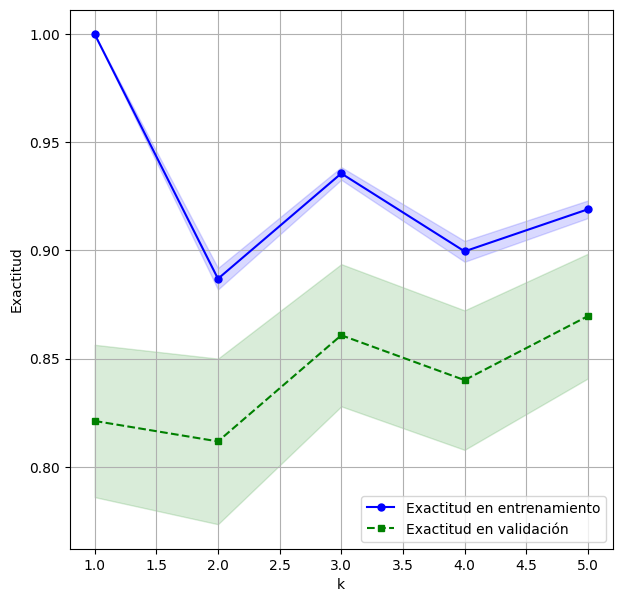

In [25]:
# Inicializamos la figura
plt.figure(figsize=(7,7))

# Creamos la curva de validación para el conjunto de entrenamiento
plt.plot(k_values, train_mean, color='blue', marker='o', markersize=5, label='Exactitud en entrenamiento')
plt.fill_between(k_values, train_mean+train_std, train_mean-train_std, alpha=0.15, color='blue')

# Creamos la curva de validación para el conjunto de validación
plt.plot(k_values, val_mean, color='green', linestyle='--', marker='s', markersize=5, label='Exactitud en validación')
plt.fill_between(k_values, val_mean+val_std, val_mean-val_std, alpha=0.15, color='green')

# Agregamos una grilla y etiquetas para los ejes
plt.grid()
plt.legend(loc='lower right')
plt.xlabel('k')
plt.ylabel('Exactitud')
plt.show()

In [26]:
best_index = np.argmax(val_mean)
best_k = k_values[best_index]
print(f"El mejor valor de k es: {best_k} con una exactitud de {val_mean[best_index]:.4f}")

El mejor valor de k es: 5 con una exactitud de 0.8696


In [27]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn_steps = [
    ('encoder', encoder),
    ('model', knn)
]

knn_pipeline = Pipeline(knn_steps).set_output(transform='pandas')

knn_pipeline 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [28]:
knn_model = knn_pipeline.fit(x_train, y_train)

knn_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain